### Importing Necessary Libraries

In [2]:
import langchain
import langgraph
from typing_extensions import Annotated,TypedDict
from langgraph.graph import StateGraph,START,END
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_groq import ChatGroq
from langchain.messages import AnyMessage
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
from datetime import datetime
from langchain_core.messages import HumanMessage,SystemMessage,AIMessage
from IPython.display import Image,display

/Users/sahildeswal/Downloads/AgenticAIWorkspace/.venv/lib/python3.12/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
/var/folders/sy/gfv5kz397jnfgcw3q_d_wjt40000gn/T/ipykernel_1224/3970140501.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults


### Setting up LLMs

In [3]:
model = ChatGroq(model="llama-3.1-8b-instant")
tavily = TavilySearchResults(max_results=3)
tool = [tavily]
llm = model.bind_tools(tool)

/var/folders/sy/gfv5kz397jnfgcw3q_d_wjt40000gn/T/ipykernel_1224/484241612.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_results=3)


### Creating State


In [4]:
class State(TypedDict):
    messages :Annotated[list[BaseMessage],add_messages]
    user_query : str
    classifier_result : str
    final_report : str

In [58]:
def user_query(state: State):
    return {
        "user_query": state["user_query"]
    }

def classifier(state: State):
    message = [
        HumanMessage(content=f"""
                     
Classify the query into only one of these categories:
- casual
- fact_check

Query: {state["user_query"]}

Provide output only: casual or fact_check
"""),
SystemMessage(content=f"""
    If the user is saying like i want to check a fact and the same thing with different manner consider it in casual talk.
For example i want to check a fact.
""")
    ]

    response = model.invoke(message)

    result = response.content.strip().lower()

    # Normalize the output
    if "casual" in result:
        result = "casual"
    else:
        result = "fact_check"

    return {"classifier_result": result}

def router(state: State):
    return state["classifier_result"]
    
def fact_check(state: State):

    claim = state["user_query"]

    vague_phrases = [
        "i want to check a fact",
        "fact check",
        "check a fact",
        "verify a fact",
        "verify news",
        "fact checking"
    ]

    if claim.lower().strip() in vague_phrases:
        response = (
            "Sure! Please tell me the specific claim or news "
            "you would like me to fact-check."
        )

        return {
            "messages": [AIMessage(content=response)],
            "final_report": response
        }

    # Search Tavily directly
    search_results = tavily.invoke(claim)

    message = [
        SystemMessage(content=f"""
You are a professional fact-checking assistant.

Today's date and time is {datetime.now()}.

Your task:
- Verify the user's claim using the provided evidence.
- Clearly state whether the claim is True, False, Partially True, or Unverified.
- Explain the reasoning.
- Provide a confidence score out of 100.
"""),

        HumanMessage(content=f"""
Claim:
{claim}

Evidence from web search:
{search_results}

Generate a final fact-check report.
""")
    ]

    response = model.invoke(message)

    return {
        "final_report": response.content,
        "messages": [AIMessage(content=response.content)]
    }

def general_chat(state: State):
    response = model.invoke(state["messages"])

    return {
        "messages": [response]
    }

    

In [59]:
from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()

In [60]:
builder = StateGraph(State)

builder.add_node("user_query",user_query)
builder.add_node("classifier",classifier)
builder.add_node("fact_check",fact_check)
builder.add_node("general_chat",general_chat)

builder.add_edge(START,"user_query")
builder.add_edge("user_query","classifier")
# builder.add_edge("classifier","router")
builder.add_conditional_edges("classifier",router,
                              {"casual":"general_chat",
                               "fact_check":"fact_check"})
builder.add_edge("general_chat",END)
builder.add_edge("fact_check",END)

graph = builder.compile(checkpointer=memory)


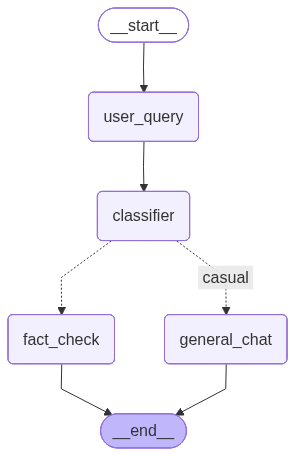

In [61]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [62]:
config1 = {
    "configurable":{"thread_id":"sahil"}
}

In [63]:
def agent_response(query, history):

    result = graph.invoke(
        {
            "user_query": query,
            "messages": [HumanMessage(content=query)]
        },
        config=config1
    )

    return result["messages"][-1].content

In [64]:
import gradio as gr

demo = gr.ChatInterface(fn=agent_response,title="Fact Checker ChatBot",description="Provide any news for fact check")
demo.launch()

* Running on local URL:  http://127.0.0.1:7868
* To create a public link, set `share=True` in `launch()`.
